<div dir="rtl" style="text-align:right; font-family:Arial,sans-serif; font-size:16px; line-height:2; background:#f0f8ff; padding:15px; border-radius:8px; border-right:5px solid #2196F3;">
<h1>أنواع التسلسل — Sequence Types</h1>
<p>التسلسل: بيانات مرتبة زمنياً أو منطقياً. أمثلة: نصوص، أصوات، درجات حرارة.</p>
</div>

![RNN Unfolded](https://upload.wikimedia.org/wikipedia/commons/thumb/b/b5/Recurrent_neural_network_unfold.svg/960px-Recurrent_neural_network_unfold.svg.png?_=20170619114714)

<div dir="rtl" style="text-align:right; font-family:Arial,sans-serif; font-size:16px; line-height:2; background:#f0f8ff; padding:15px; border-radius:8px; border-right:5px solid #2196F3;">
<h2>أنواع مسائل التسلسل</h2>
<table border="1" style="width:100%; border-collapse:collapse; text-align:right; direction:rtl;">
<thead style="background:#2196F3; color:white;">
<tr><th style="padding:10px;">النوع</th><th style="padding:10px;">مثال</th></tr>
</thead>
<tbody>
<tr style="background:#f9f9f9;"><td style="padding:8px;">واحد-لواحد (1→1)</td><td style="padding:8px;">التنبوء بحالة المطر بناءا على درجة الحرارة فقط</td></tr>
<tr><td style="padding:8px;">واحد-لمتعدد (1→N)</td><td style="padding:8px;">توليد نص من صورة</td></tr>
<tr style="background:#f9f9f9;"><td style="padding:8px;">متعدد-لواحد (N→1)</td><td style="padding:8px;">تحليل مشاعر جملة</td></tr>
<tr><td style="padding:8px;">متعدد-لمتعدد (N→N)</td><td style="padding:8px;">ترجمة آلية</td></tr>
</tbody>
</table>
</div>

![Sequence Types](https://karpathy.github.io/assets/rnn/diags.jpeg)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences

print(f"TensorFlow: {tf.__version__}")

# تسلسل رقمي
seq = list(range(1, 11))
print("تسلسل رقمي:", seq)

# تسلسل نصي
text  = "التعلم العميق"
chars = list(text)
print("تسلسل نصي:", chars)

TensorFlow: 2.18.0
تسلسل رقمي: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
تسلسل نصي: ['ا', 'ل', 'ت', 'ع', 'ل', 'م', ' ', 'ا', 'ل', 'ع', 'م', 'ي', 'ق']


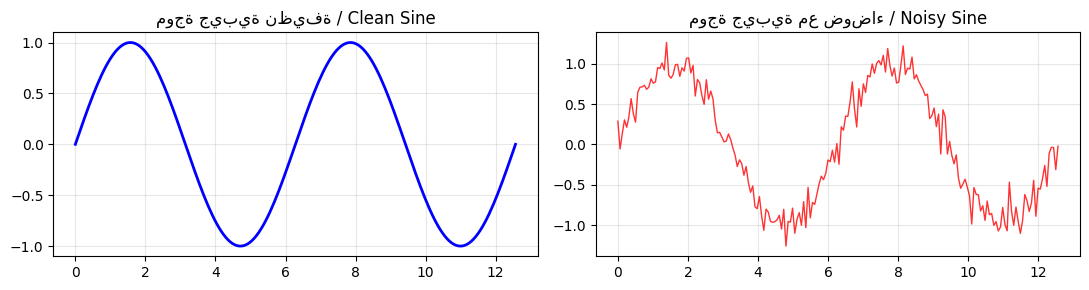

In [12]:
t = np.linspace(0, 4 * np.pi, 200)
clean = np.sin(t)
noisy = clean + np.random.normal(0, 0.15, len(t))

plt.figure(figsize=(11, 3))
plt.subplot(1, 2, 1)
plt.plot(t, clean, 'b-', linewidth=2)
plt.title('موجة جيبية نظيفة / Clean Sine')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(t, noisy, 'r-', linewidth=1, alpha=0.8)
plt.title('موجة جيبية مع ضوضاء / Noisy Sine')
plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

<div dir="rtl" style="text-align:right; font-family:Arial,sans-serif; font-size:16px; line-height:2; background:#f0f8ff; padding:15px; border-radius:8px; border-right:5px solid #2196F3;">
<h2>النافذة المنزلقة — Sliding Window</h2>
<p>طريقة تحويل السلسلة الزمنية إلى أزواج (X, y): نأخذ نافذة من N خطوة كمدخل، والقيمة التالية كهدف، ثم نُزحزح النافذة خطوة للأمام.</p>
</div>

In [7]:
def make_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

data = np.sin(np.linspace(0, 6*np.pi, 300)).astype(np.float32)
X, y = make_sequences(data, seq_len=30)
print(f"X الشكل: {X.shape}  — (عينات, طول التسلسل)")
print(f"y الشكل: {y.shape}  — (عينات,)")

X الشكل: (270, 30)  — (عينات, طول التسلسل)
y الشكل: (270,)  — (عينات,)


In [9]:
# حشو التسلسلات المتفاوتة الأطوال
sentences = [[1, 2, 3], [4, 5], [6, 7, 8, 9, 10]]
padded = pad_sequences(sentences, maxlen=6, padding='post')
print("بعد الحشو:\n", padded)
print("الشكل:", padded.shape)

بعد الحشو:
 [[ 1  2  3  0  0  0]
 [ 4  5  0  0  0  0]
 [ 6  7  8  9 10  0]]
الشكل: (3, 6)
